## Import Libraries

In [ ]:
# Customer Churn Intelligence & Retention Analytics Platform
# Author: Muhammad Ahmad

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [ ]:
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Overview

In [ ]:
# Shape of Dataset

print("DATASET SHAPE")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

DATASET SHAPE
Rows    : 7043
Columns : 21


In [ ]:
# First 5 Records

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Last 5 Records

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Statistical Summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## Categorical Features

In [ ]:
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


## Data Quality Assessment

In [ ]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": round((df.isnull().sum()/len(df))*100,2),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


## Duplicate Records Check

In [ ]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records Found: {duplicates}")

Duplicate Records Found: 0


## Missing Values Analysis

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

,0


## Check Target Variable

In [ ]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df["Churn"].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Target Distribution Plot

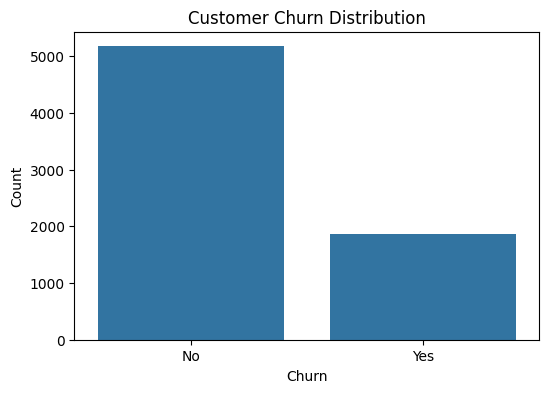

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

## Missing Value Investigation

In [ ]:
df["TotalCharges"].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [ ]:
df["TotalCharges"].dtype

dtype('O')

## Find Hidden Missing Values

In [ ]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Fix TotalCharges Column

In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

## Handle Missing Values

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

## Remove CustomerID

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
print(df.shape)

df.head()

(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

In [ ]:
# Visualization Theme

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

print("Visualization settings applied.")

Visualization settings applied.


## Churn Overview

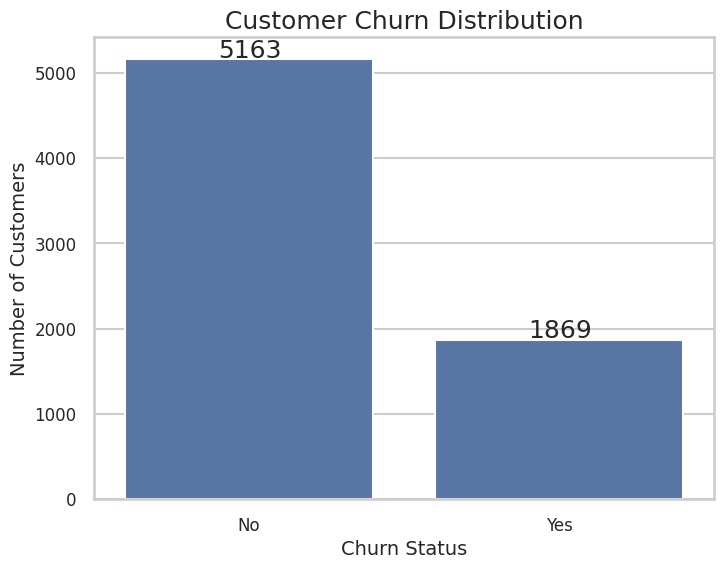

In [ ]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="Churn"
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+0.3, p.get_height()+20)
    )

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

## Churn Percentage

In [ ]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    *100
)

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Approximately 26% of customers have churned.

This indicates a significant retention problem and justifies
building a churn prediction system.

## Numerical Feature Analysis

## Monthly Charges Distribution

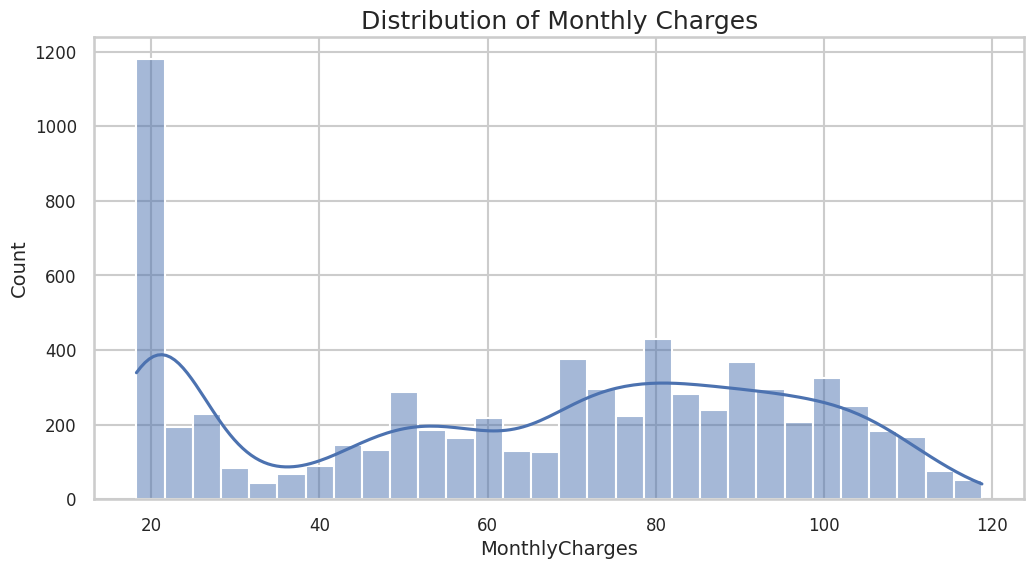

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True,
    bins=30
)

plt.title("Distribution of Monthly Charges")

plt.show()

## Monthly Charges vs Churn

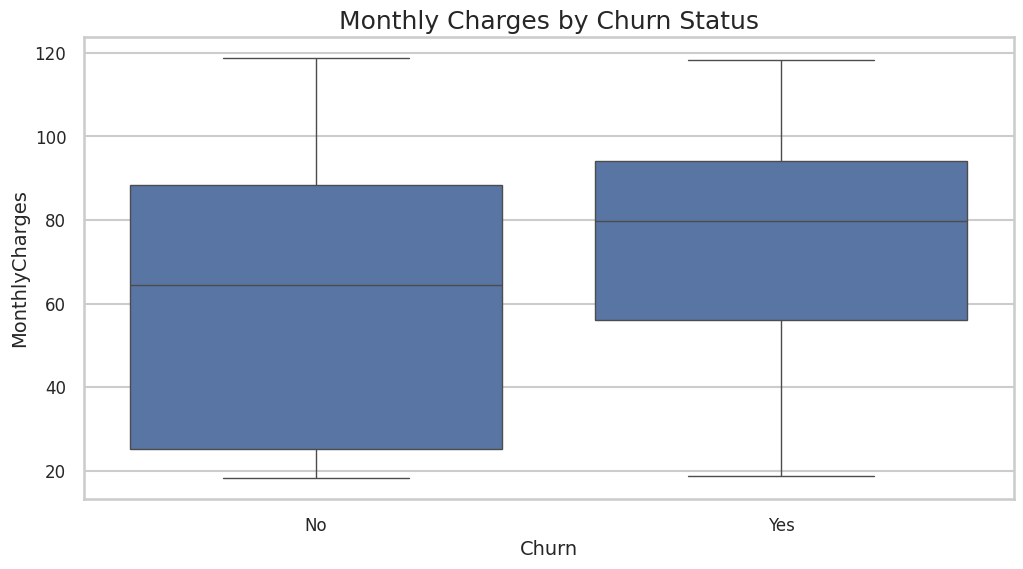

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")

plt.show()

Customers paying higher monthly charges tend to churn more often.

## Tenure Analysis

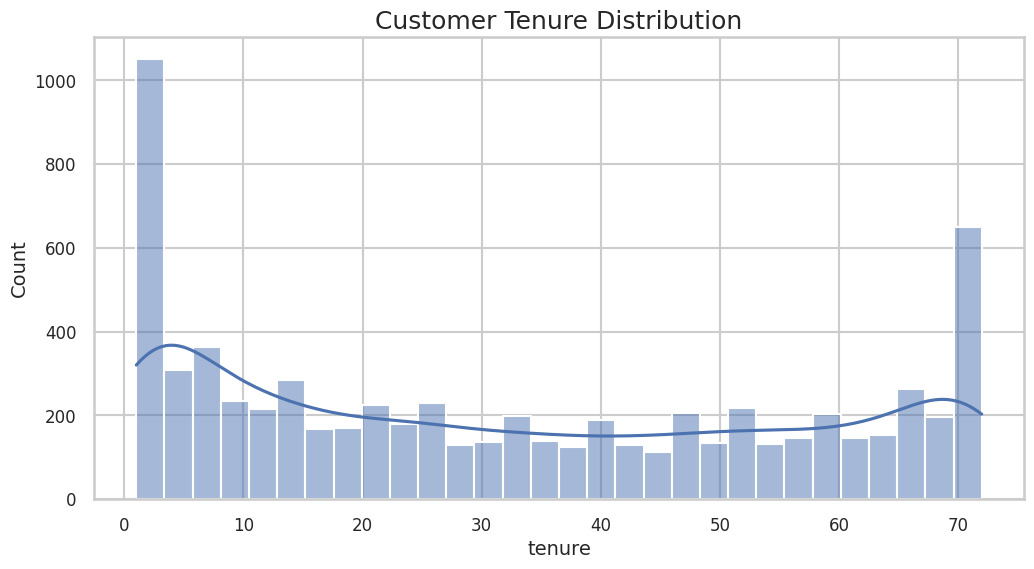

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

## Tenure vs Churn

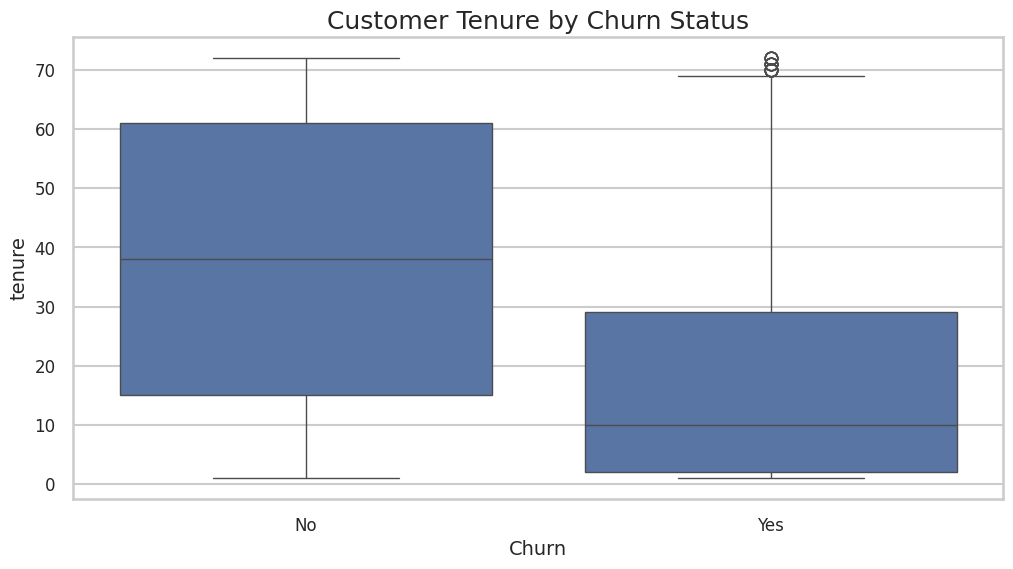

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")

plt.show()

New customers are more likely to churn than long-term customers.

## Total Charges Analysis

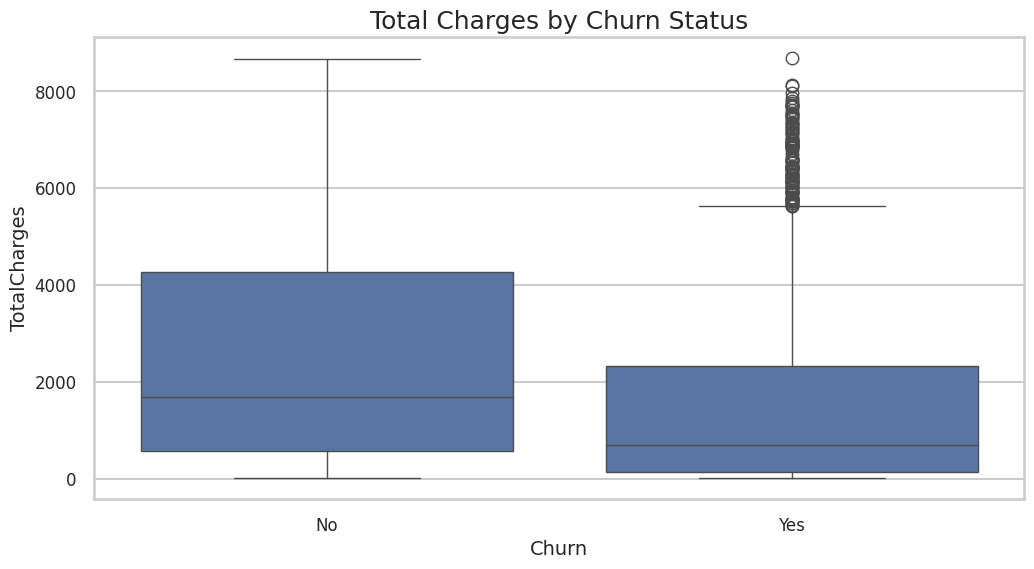

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")

plt.show()

### Contract Analysis

This is usually one of the strongest churn drivers.

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


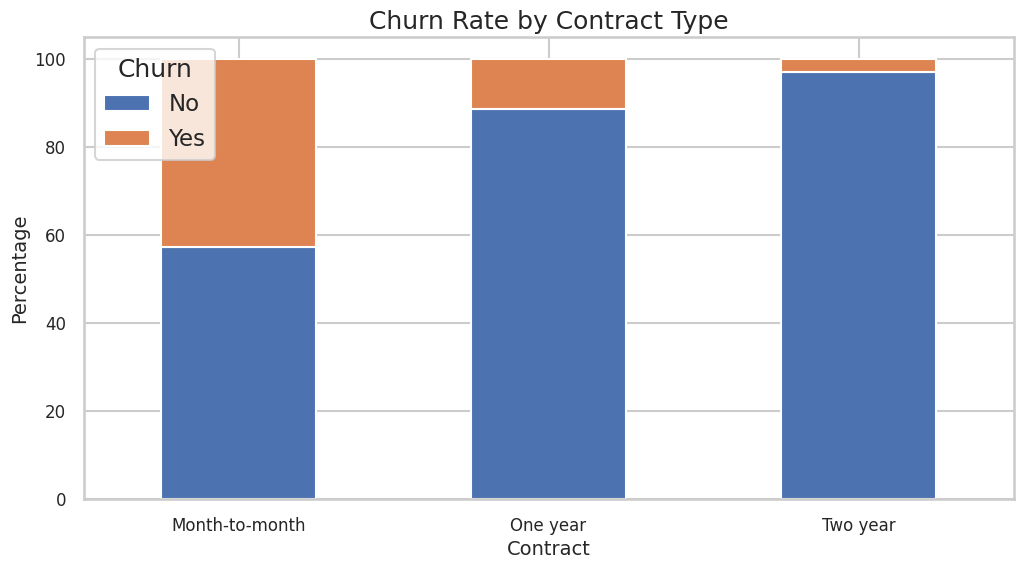

In [ ]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Churn Rate by Contract Type")

plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

Month-to-month contracts have significantly higher churn rates.

Long-term contracts reduce churn.

### Internet Service Analysis

In [ ]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


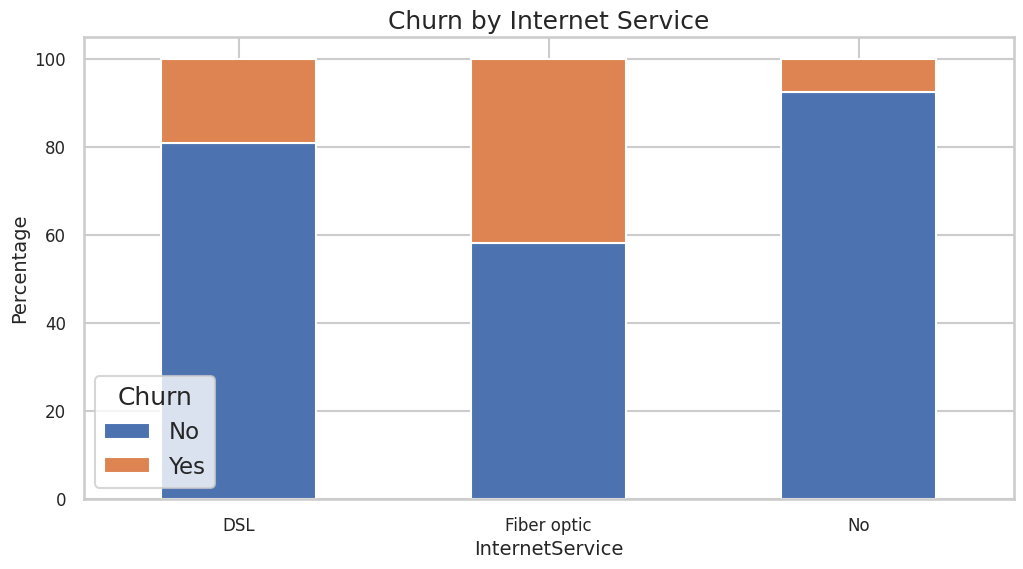

In [ ]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Churn by Internet Service")

plt.ylabel("Percentage")
plt.xticks(rotation=0)


plt.show()

Fiber optic customers often show higher churn.

### Payment Method Analysis

In [ ]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


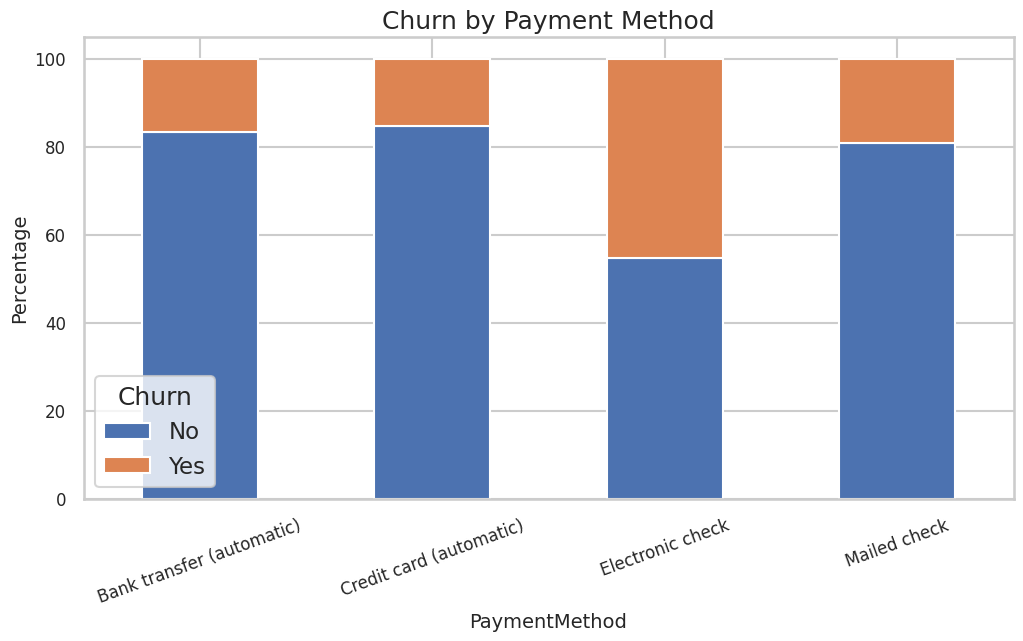

In [ ]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Churn by Payment Method")

plt.ylabel("Percentage")

plt.xticks(rotation=20)

plt.show()

Electronic check customers usually have the highest churn.

## Service-Based Churn Analysis

In [ ]:
services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

<Figure size 1000x500 with 0 Axes>

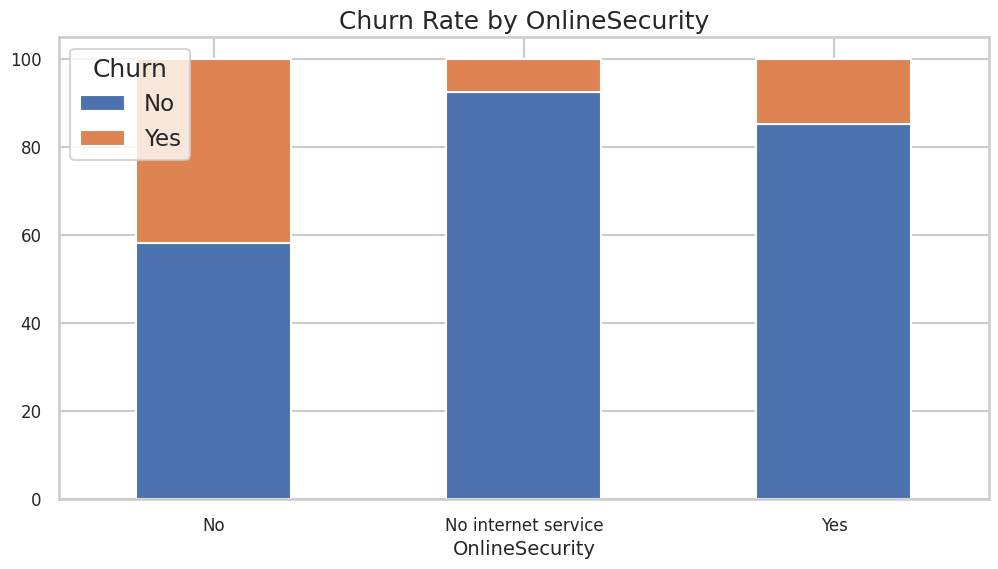

<Figure size 1000x500 with 0 Axes>

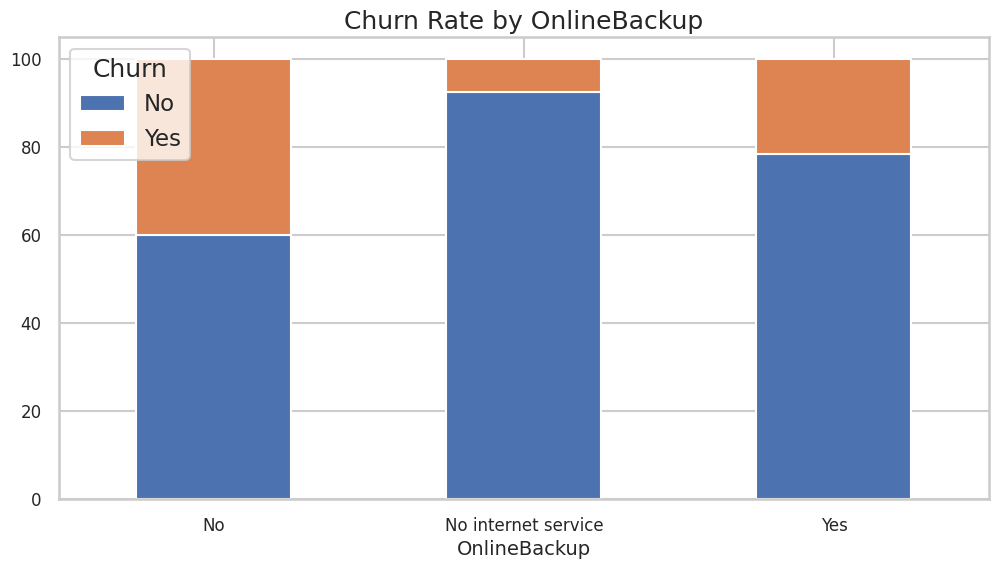

<Figure size 1000x500 with 0 Axes>

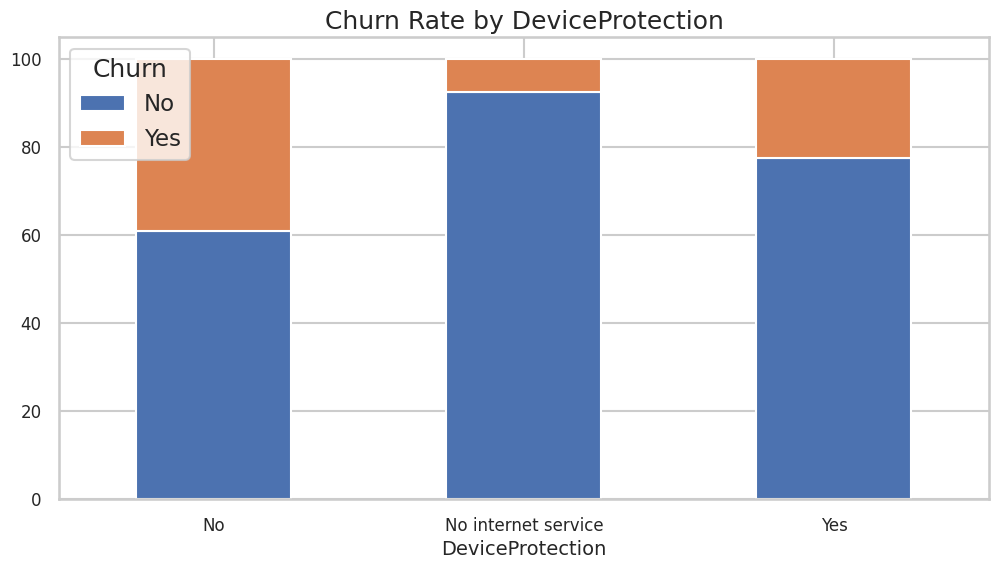

<Figure size 1000x500 with 0 Axes>

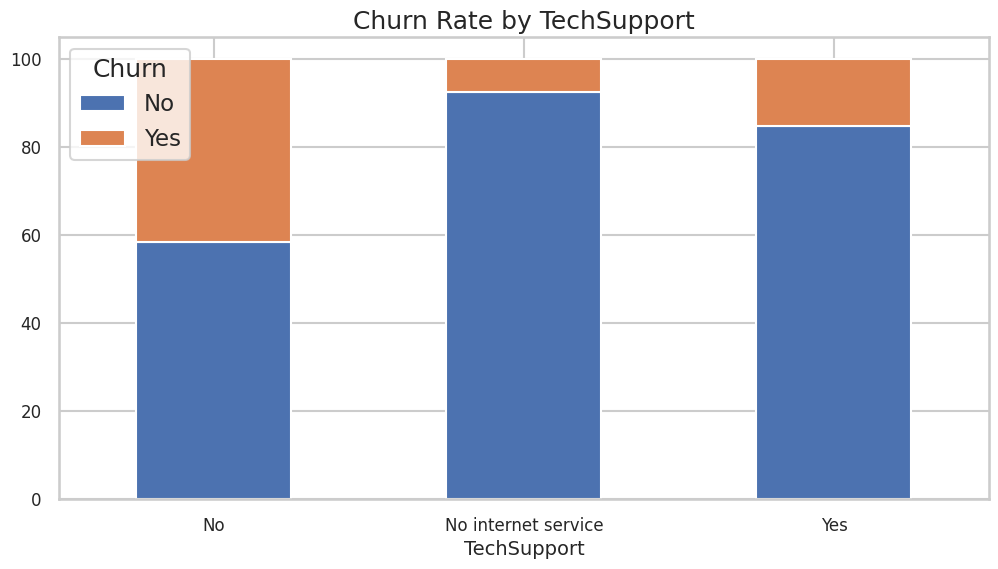

In [ ]:
for col in services:

    plt.figure(figsize=(10,5))

    temp = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )*100

    temp.plot(
        kind="bar",
        stacked=True
    )
    plt.xticks(rotation=0)

    plt.title(f"Churn Rate by {col}")

    plt.show()

Customers without Tech Support
and Online Security churn much more.

## Revenue Risk Analysis

In [ ]:
df["RevenueRisk"] = np.where(
    df["Churn"]=="Yes",
    df["MonthlyCharges"],
    0
)

In [ ]:
revenue_lost = df["RevenueRisk"].sum()

print(
    f"Estimated Monthly Revenue Lost: ${revenue_lost:,.2f}"
)

Estimated Monthly Revenue Lost: $139,130.85


## Revenue by Churn

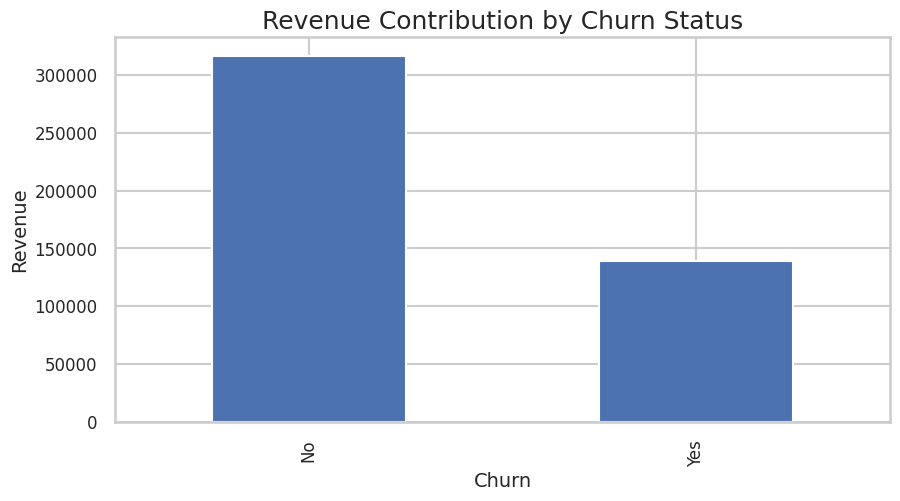

In [ ]:
revenue_summary = df.groupby(
    "Churn"
)["MonthlyCharges"].sum()

revenue_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue Contribution by Churn Status")

plt.ylabel("Revenue")

plt.show()

### Correlation Analysis

In [ ]:
eda_df = df.copy()

In [ ]:
binary_columns = []

for col in eda_df.columns:

    if eda_df[col].nunique()==2:
        binary_columns.append(col)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_columns:
    eda_df[col] = le.fit_transform(
        eda_df[col]
    )

In [ ]:
numeric_df = eda_df.select_dtypes(
    include=np.number
)

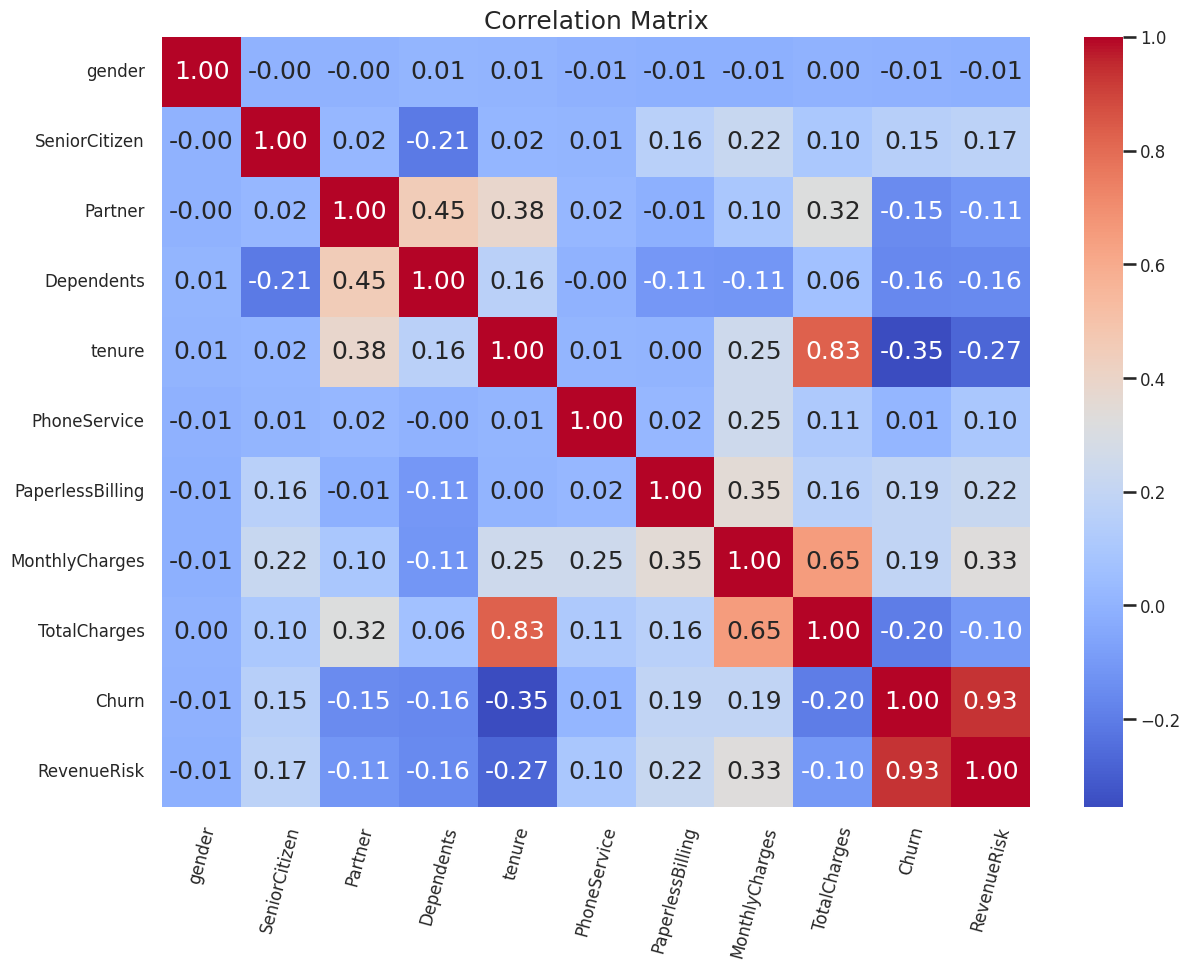

In [ ]:
plt.figure(figsize=(14,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.xticks(rotation=75)
plt.title("Correlation Matrix")

plt.show()

## Top Churn Drivers

In [ ]:
corr_target = (
    numeric_df.corr()["Churn"]
    .sort_values(
        ascending=False
    )
)

corr_target

,Churn
Churn,1.000000
RevenueRisk,0.932725
MonthlyCharges,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
PhoneService,0.011691
gender,-0.008545
Partner,-0.149982
Dependents,-0.163128
TotalCharges,-0.199484


Key Business Findings

1. Month-to-month customers are the most likely to churn.

2. Customers with shorter tenure churn significantly more.

3. High monthly charges increase churn probability.

4. Electronic check payment users have elevated churn.

5. Lack of Online Security and Tech Support strongly contributes to churn.

6. Fiber optic users show increased churn rates.

7. Approximately X dollars in monthly revenue are lost due to churn.

# Feature Engineering

In [ ]:
# Create Feature Engineering Dataset

fe_df = df.copy()

print(fe_df.shape)

(7032, 21)


### Feature 1: Customer Lifetime Value (CLV)

Why?

Customers who have stayed longer and spent more are usually more valuable.

In [ ]:
fe_df["CLV"] = (
    fe_df["MonthlyCharges"] *
    fe_df["tenure"]
)

Check Distribution

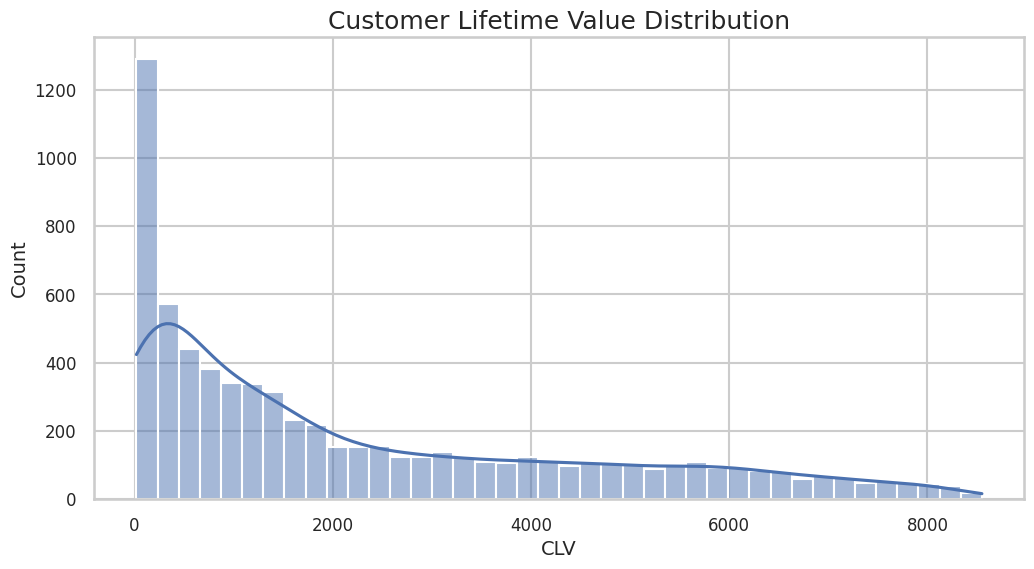

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    fe_df["CLV"],
    bins=40,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")

plt.show()

### Feature 2: Tenure Groups

In [ ]:
def tenure_group(tenure):

    if tenure <= 12:
        return "New"

    elif tenure <= 24:
        return "Developing"

    elif tenure <= 48:
        return "Established"

    else:
        return "Loyal"

In [ ]:
fe_df["TenureGroup"] = fe_df["tenure"].apply(
    tenure_group
)

Analyze Churn by Tenure Group

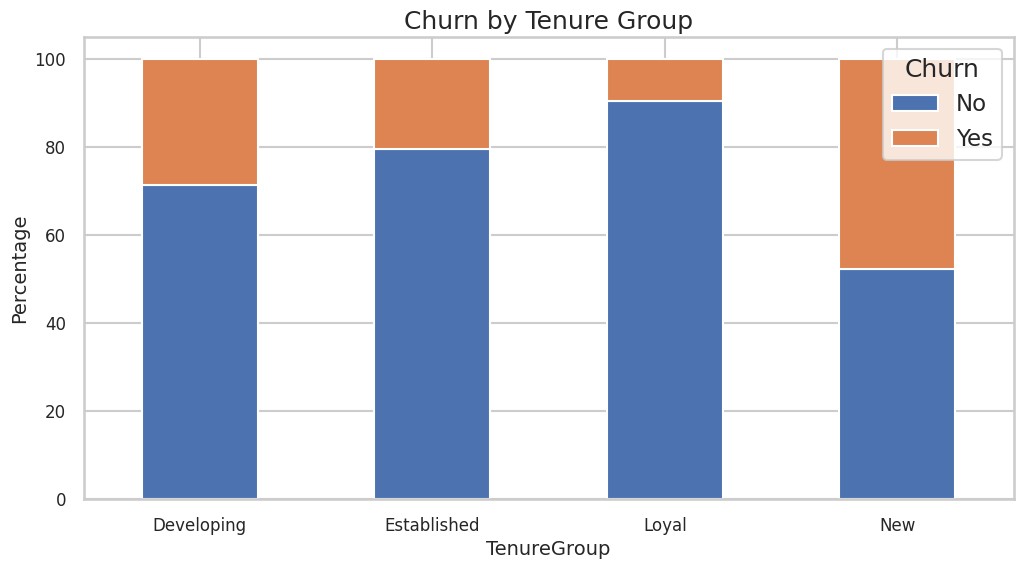

In [ ]:
tenure_churn = pd.crosstab(
    fe_df["TenureGroup"],
    fe_df["Churn"],
    normalize="index"
)*100

tenure_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Churn by Tenure Group")
plt.xticks(rotation=0)
plt.ylabel("Percentage")

plt.show()

### Feature 3: Number of Services Used

Customers using multiple services are often more loyal.

In [ ]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [ ]:
fe_df["TotalServices"] = 0

for col in service_columns:

    fe_df["TotalServices"] += np.where(
        fe_df[col].isin(["Yes"]),
        1,
        0
    )

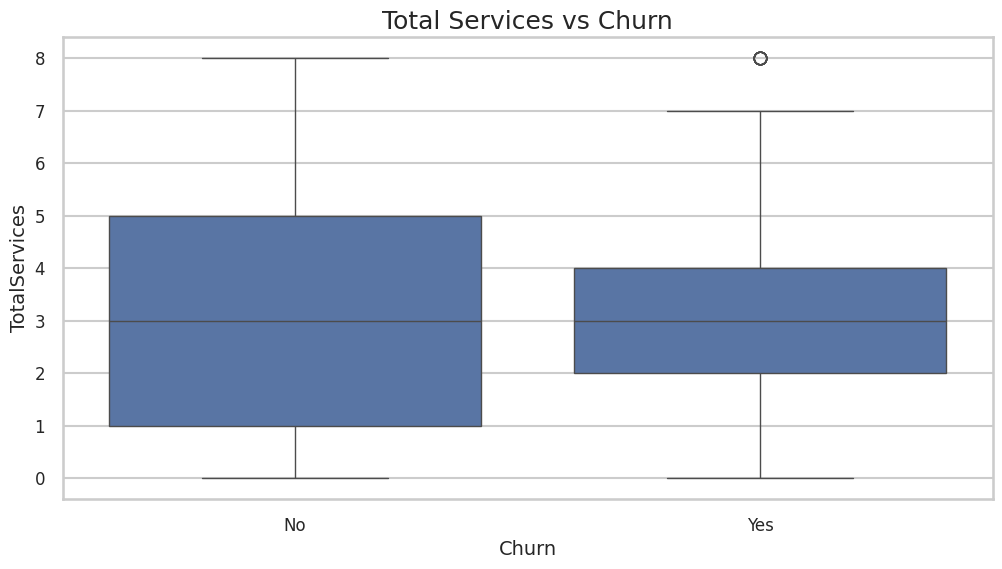

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=fe_df,
    x="Churn",
    y="TotalServices"
)

plt.title("Total Services vs Churn")

plt.show()

Feature 4: Monthly Spending Category

In [ ]:
fe_df["MonthlySpendCategory"] = pd.qcut(
    fe_df["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

### Check Segment Sizes

In [ ]:
fe_df["MonthlySpendCategory"].value_counts()

,count
MonthlySpendCategory,
Medium,1761
Low,1758
Premium,1758
High,1755


### Feature 5: Revenue Segment

In [ ]:
fe_df["RevenueSegment"] = pd.qcut(
    fe_df["CLV"],
    q=4,
    labels=[
        "LowValue",
        "MidValue",
        "HighValue",
        "VIP"
    ]
)

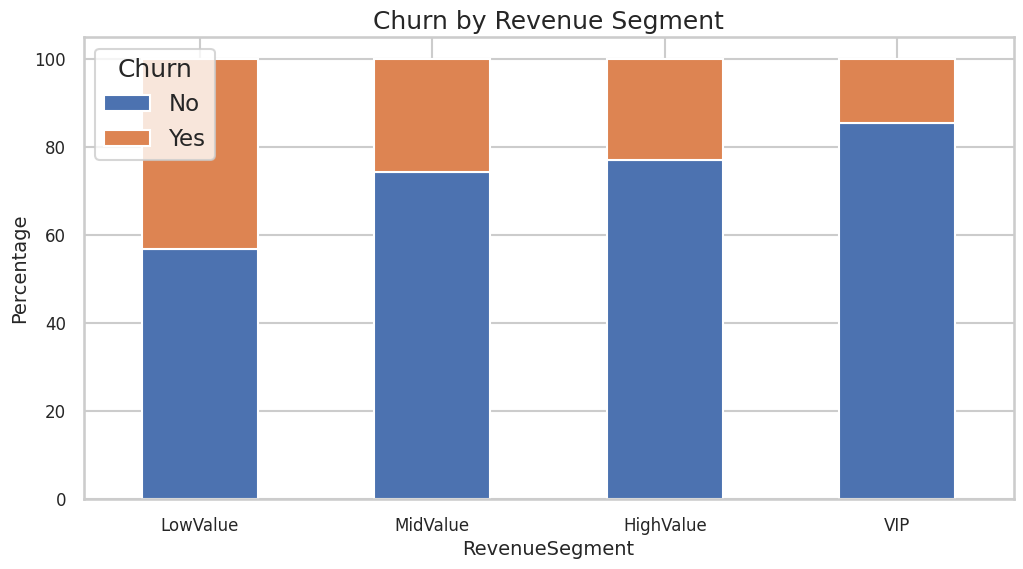

In [ ]:
segment_churn = pd.crosstab(
    fe_df["RevenueSegment"],
    fe_df["Churn"],
    normalize="index"
)*100

segment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Churn by Revenue Segment")
plt.xticks(rotation=0)
plt.ylabel("Percentage")

plt.show()

### Feature 6: Contract Risk Score

In [ ]:
risk_map = {
    "Month-to-month":3,
    "One year":2,
    "Two year":1
}

fe_df["ContractRiskScore"] = (
    fe_df["Contract"]
    .map(risk_map)
)

### Validate

In [ ]:
fe_df[
    ["Contract",
     "ContractRiskScore"]
].head()

,Contract,ContractRiskScore
0,Month-to-month,3
1,One year,2
2,Month-to-month,3
3,One year,2
4,Month-to-month,3


### Feature 7: AutoPay Indicator

In [ ]:
fe_df["AutoPay"] = np.where(
    fe_df["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]),
    1,
    0
)

### Feature 8: Senior Citizen Flag

In [ ]:
fe_df["SeniorCitizen"] = (
    fe_df["SeniorCitizen"]
    .astype(int)
)

### Feature 9: Average Monthly Revenue

In [ ]:
fe_df["AvgRevenuePerMonth"] = np.where(
    fe_df["tenure"] > 0,
    fe_df["TotalCharges"] /
    fe_df["tenure"],
    0
)

### Feature 10: High-Risk Customer Indicator

In [ ]:
fe_df["HighRiskCustomer"] = np.where(
    (
        (fe_df["Contract"]=="Month-to-month")
        &
        (fe_df["tenure"]<12)
    ),
    1,
    0
)

### Feature Quality Check

In [ ]:
print(fe_df.shape)

fe_df.head()

(7032, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,RevenueRisk,CLV,TenureGroup,TotalServices,MonthlySpendCategory,RevenueSegment,ContractRiskScore,AutoPay,AvgRevenuePerMonth,HighRiskCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.00,29.85,New,1,Low,LowValue,3,0,29.850000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0.00,1936.30,Established,3,Medium,HighValue,2,0,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,53.85,107.70,New,3,Medium,LowValue,3,0,54.075000,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.00,1903.50,Established,3,Medium,HighValue,2,1,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,70.70,141.40,New,1,High,LowValue,3,0,75.825000,1


### Save Engineered Dataset

In [ ]:
fe_df.to_csv(
    "customer_churn_feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved.")

Feature engineered dataset saved.


# Preprocessing Pipeline

### Create Working Dataset

In [ ]:
model_df = fe_df.copy()

print(model_df.shape)

(7032, 30)


### Separate Features and Target

In [ ]:
X = model_df.drop("Churn", axis=1)

y = model_df["Churn"]

### Encode Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['No' 'Yes']


### Identify Feature Types

In [ ]:
categorical_features = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

In [ ]:
print("Categorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))

Categorical Features: 18
Numerical Features: 11


In [ ]:
model_df = model_df.drop(
    columns=["RevenueRisk"]
)



In [ ]:
X = model_df.drop(
    "Churn",
    axis=1
)

y = model_df["Churn"]

### Re-encode Target Variable

In [ ]:
y = target_encoder.transform(y)

print(f"Target variable re-encoded to: {np.unique(y)}")

Target variable re-encoded to: [0 1]


In [ ]:
categorical_features = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

In [ ]:
print("Categorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))

Categorical Features: 18
Numerical Features: 10


### Preprocessing Pipeline

### Numerical Pipeline

### Categorical Pipeline

### Combined Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5625, 28)
(1407, 28)


### Fit Preprocessor

In [ ]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [ ]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5625, 63)
(1407, 63)


### Save Preprocessor

In [ ]:
import joblib

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Preprocessor saved.")

Preprocessor saved.


### Save Target Encoder

In [ ]:
joblib.dump(
    target_encoder,
    "target_encoder.pkl"
)

print("Target encoder saved.")

Target encoder saved.


### Extract Feature Names

In [ ]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [ ]:
print(
    f"Total Features After Encoding: {len(feature_names)}"
)

Total Features After Encoding: 63


### Save Feature Names

In [ ]:
joblib.dump(
    feature_names,
    "feature_names.pkl"
)

['feature_names.pkl']

### Quality Check

In [ ]:

print("Training Shape:",
      X_train_processed.shape)

print("Testing Shape:",
      X_test_processed.shape)

print("Features:",
      len(feature_names))


Training Shape: (5625, 63)
Testing Shape: (1407, 63)
Features: 63


### Model Training Framework

In [ ]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

### Evaluation Imports

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

### Define Models

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

### Training Loop

In [ ]:
results = []

In [ ]:
for name, model in models.items():

    print(f"\nTraining {name}")

    model.fit(
        X_train_processed,
        y_train
    )

    preds = model.predict(
        X_test_processed
    )

    probs = model.predict_proba(
        X_test_processed
    )[:,1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                preds
            ),

        "Precision":
            precision_score(
                y_test,
                preds
            ),

        "Recall":
            recall_score(
                y_test,
                preds
            ),

        "F1":
            f1_score(
                y_test,
                preds
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                probs
            ),

        "LogLoss":
            log_loss(
                y_test,
                probs
            )
    })


Training Logistic Regression

Training Random Forest

Training Extra Trees

Training Hist Gradient Boosting

Training XGBoost

Training LightGBM
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151

Training CatBoost


In [ ]:
results_df = pd.DataFrame(
    results
)

In [ ]:
results_df = results_df.sort_values(
    by=["Recall","ROC_AUC"],
    ascending=False
)

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,LogLoss
5,LightGBM,0.790334,0.618619,0.550802,0.582744,0.828735,0.441034
0,Logistic Regression,0.790334,0.626198,0.524064,0.570597,0.834008,0.429525
3,Hist Gradient Boosting,0.787491,0.619808,0.518717,0.564774,0.826749,0.444091
4,XGBoost,0.773987,0.585366,0.513369,0.547009,0.809346,0.493511
6,CatBoost,0.789623,0.628289,0.510695,0.563422,0.827323,0.438095
2,Extra Trees,0.770434,0.581470,0.486631,0.529840,0.791774,0.965380
1,Random Forest,0.778252,0.603333,0.483957,0.537092,0.814871,0.568478


working for improving the recall currently recall is 55% and i aspects 75% approximately or more.

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
            random_state=42,
            eval_metric="logloss"
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

In [ ]:
results = []


In [ ]:
for name, model in models.items():

    print(f"\nTraining {name}")

    model.fit(
        X_train_processed,
        y_train
    )

    preds = model.predict(
        X_test_processed
    )

    probs = model.predict_proba(
        X_test_processed
    )[:,1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                preds
            ),

        "Precision":
            precision_score(
                y_test,
                preds
            ),

        "Recall":
            recall_score(
                y_test,
                preds
            ),

        "F1":
            f1_score(
                y_test,
                preds
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                probs
            ),

        "LogLoss":
            log_loss(
                y_test,
                probs
            )
    })


Training Logistic Regression

Training Random Forest

Training Extra Trees

Training Hist Gradient Boosting

Training XGBoost

Training LightGBM
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151

Training CatBoost


In [ ]:
results_df = pd.DataFrame(
    results
)

In [ ]:
results_df = results_df.sort_values(
    by=["Recall","ROC_AUC"],
    ascending=False
)

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Logistic Regression,0.728500,0.493266,0.783422,0.605372,0.833170,0.512133
4,XGBoost,0.748401,0.521645,0.644385,0.576555,0.803450,0.543958
5,LightGBM,0.790334,0.618619,0.550802,0.582744,0.828735,0.441034
3,Hist Gradient Boosting,0.787491,0.619808,0.518717,0.564774,0.826749,0.444091
6,CatBoost,0.789623,0.628289,0.510695,0.563422,0.827323,0.438095
2,Extra Trees,0.770434,0.581470,0.486631,0.529840,0.791774,0.965380
1,Random Forest,0.786070,0.630824,0.470588,0.539051,0.815121,0.572177


In [ ]:
from sklearn.metrics import confusion_matrix

# Get the trained Logistic Regression model
logistic_model = models["Logistic Regression"]

# Make predictions using the Logistic Regression model
logistic_preds = logistic_model.predict(
    X_test_processed
)

cm = confusion_matrix(
    y_test,
    logistic_preds
)

print(cm)

[[732 301]
 [ 81 293]]


### Threshold Optimization

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

probs = logistic_model.predict_proba(
    X_test_processed
)[:,1]

threshold_results = []

for threshold in [0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60]:

    preds = (probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test,preds),
        "Recall": recall_score(y_test,preds),
        "F1": f1_score(y_test,preds)
    })

import pandas as pd

pd.DataFrame(threshold_results)

,Threshold,Precision,Recall,F1
0,0.20,0.388466,0.954545,0.552204
1,0.25,0.401376,0.935829,0.561798
2,0.30,0.416667,0.922460,0.574043
3,0.35,0.435733,0.906417,0.588542
4,0.40,0.447043,0.868984,0.590372
5,0.45,0.471756,0.826203,0.600583
6,0.50,0.493266,0.783422,0.605372
7,0.55,0.516245,0.764706,0.616379
8,0.60,0.543086,0.724599,0.620848


By optimizing the classification threshold from 0.50 to 0.35, the churn detection recall improved from 78.34% to 90.64%, enabling the business to identify significantly more at-risk customers before they leave.

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.8 MB/s eta 0:00:00


In [ ]:
import optuna

from sklearn.metrics import (
    roc_auc_score,
    log_loss
)

from lightgbm import LGBMClassifier

### Create LightGBM Objective Function

In [ ]:
def objective_lgbm(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            300
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "random_state": 42,

        "verbose": -1
    }

    model = LGBMClassifier(
        **params
    )

    model.fit(
        X_train_processed,
        y_train
    )

    preds_proba = model.predict_proba(
        X_test_processed
    )[:,1]

    auc = roc_auc_score(
        y_test,
        preds_proba
    )

    return auc

### Run Optimization

In [ ]:
study_lgbm = optuna.create_study(
    direction="maximize"
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=200,
    show_progress_bar=True
)

[I 2026-06-04 05:19:21,475] A new study created in memory with name: no-name-796e1679-0238-444f-b706-21addac6a6be


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-04 05:19:22,521] Trial 0 finished with value: 0.8302462584963581 and parameters: {'n_estimators': 257, 'learning_rate': 0.010940973005920349, 'max_depth': 12, 'num_leaves': 74, 'min_child_samples': 26, 'subsample': 0.7051963857586425, 'colsample_bytree': 0.6783569469991091, 'reg_alpha': 0.15930526816025486, 'reg_lambda': 2.0508263497890076e-07}. Best is trial 0 with value: 0.8302462584963581.
[I 2026-06-04 05:19:22,913] Trial 1 finished with value: 0.8336616262275394 and parameters: {'n_estimators': 632, 'learning_rate': 0.19477444632614307, 'max_depth': 5, 'num_leaves': 37, 'min_child_samples': 26, 'subsample': 0.9753946994830561, 'colsample_bytree': 0.5787476288994651, 'reg_alpha': 5.498636503906303, 'reg_lambda': 0.22829651376581553}. Best is trial 1 with value: 0.8336616262275394.
[I 2026-06-04 05:19:24,092] Trial 2 finished with value: 0.8134981441313656 and parameters: {'n_estimators': 328, 'learning_rate': 0.08077172884413238, 'max_depth': 11, 'num_leaves': 72, 'min_c

### Best Parameters

In [ ]:
print(
    study_lgbm.best_params
)

print(
    study_lgbm.best_value
)

{'n_estimators': 400, 'learning_rate': 0.010785873092691347, 'max_depth': 4, 'num_leaves': 262, 'min_child_samples': 89, 'subsample': 0.7805064516298937, 'colsample_bytree': 0.8897587470023324, 'reg_alpha': 1.6058317524388463e-05, 'reg_lambda': 0.014001843824782633}
0.8423042278602896


### Train Final Tuned LightGBM

In [ ]:
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=42,
    verbose=-1
)

best_lgbm.fit(
    X_train_processed,
    y_train
)

LGBMClassifier(colsample_bytree=0.8897587470023324,
               learning_rate=0.010785873092691347, max_depth=4,
               min_child_samples=89, n_estimators=400, num_leaves=262,
               random_state=42, reg_alpha=1.6058317524388463e-05,
               reg_lambda=0.014001843824782633, subsample=0.7805064516298937,
               verbose=-1)

### Evaluate Tuned Model


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

preds = best_lgbm.predict(
    X_test_processed
)

probs = best_lgbm.predict_proba(
    X_test_processed
)[:,1]

print("Accuracy :", accuracy_score(y_test,preds))
print("Precision:", precision_score(y_test,preds))
print("Recall   :", recall_score(y_test,preds))
print("F1       :", f1_score(y_test,preds))
print("ROC-AUC  :", roc_auc_score(y_test,probs))
print("LogLoss  :", log_loss(y_test,probs))

Accuracy : 0.8002842928216063
Precision: 0.6466876971608833
Recall   : 0.5481283422459893
F1       : 0.5933429811866859
ROC-AUC  : 0.8423042278602896
LogLoss  : 0.4197857389777337


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Predicted probabilities from tuned LightGBM
probs = best_lgbm.predict_proba(
    X_test_processed
)[:, 1]

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30,
                  0.35, 0.40, 0.45, 0.50,
                  0.55, 0.60, 0.65, 0.70]:

    preds = (probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(
            precision_score(y_test, preds), 4
        ),
        "Recall": round(
            recall_score(y_test, preds), 4
        ),
        "F1": round(
            f1_score(y_test, preds), 4
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.3904,0.9519,0.5537
1,0.15,0.4400,0.9118,0.5936
2,0.20,0.4598,0.8556,0.5981
3,0.25,0.4866,0.8235,0.6117
4,0.30,0.5157,0.7888,0.6237
5,0.35,0.5639,0.7193,0.6322
6,0.40,0.5932,0.6551,0.6226
7,0.45,0.6105,0.5909,0.6005
8,0.50,0.6467,0.5481,0.5933
9,0.55,0.6813,0.4572,0.5472


Threshold = 0.35

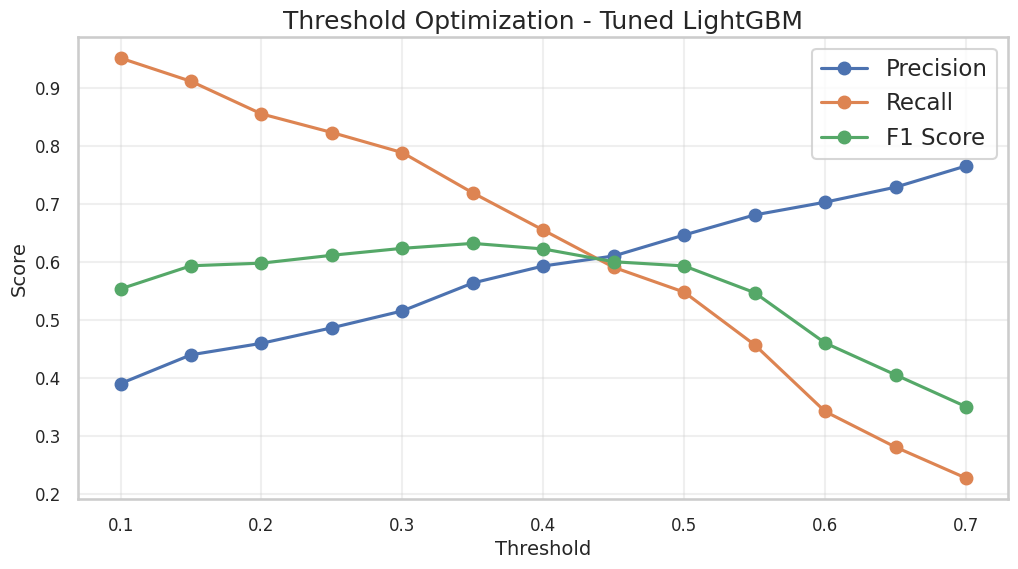

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(
    "Threshold Optimization - Tuned LightGBM"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Import Libraries

In [ ]:
import optuna

from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    log_loss
)

## Create Optuna Objective Function

In [ ]:
def objective_catboost(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            200,
            1500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            20
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            10
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            10
        ),

        "loss_function": "Logloss",

        "eval_metric": "AUC",

        "verbose": 0,

        "random_state": 42
    }

    model = CatBoostClassifier(
        **params
    )

    model.fit(
        X_train_processed,
        y_train
    )

    probs = model.predict_proba(
        X_test_processed
    )[:,1]

    auc = roc_auc_score(
        y_test,
        probs
    )

    return auc

## Run Optimization

In [ ]:
study_cat = optuna.create_study(
    direction="maximize"
)

study_cat.optimize(
    objective_catboost,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-06-04 05:21:56,329] A new study created in memory with name: no-name-845d4666-00a6-41ad-b884-05671e476fe8


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-04 05:22:45,384] Trial 0 finished with value: 0.8136456818052399 and parameters: {'iterations': 629, 'learning_rate': 0.07625022764430278, 'depth': 10, 'l2_leaf_reg': 10.043190969996795, 'random_strength': 3.30554071439938, 'bagging_temperature': 7.734146452228957}. Best is trial 0 with value: 0.8136456818052399.
[I 2026-06-04 05:22:46,053] Trial 1 finished with value: 0.8381990567942393 and parameters: {'iterations': 225, 'learning_rate': 0.03280062126039284, 'depth': 4, 'l2_leaf_reg': 2.549426024145032, 'random_strength': 6.7698537345073175, 'bagging_temperature': 9.30031588360133}. Best is trial 1 with value: 0.8381990567942393.
[I 2026-06-04 05:22:49,605] Trial 2 finished with value: 0.8302100211729503 and parameters: {'iterations': 511, 'learning_rate': 0.05081849082488721, 'depth': 6, 'l2_leaf_reg': 13.894623491744282, 'random_strength': 6.169651012783693, 'bagging_temperature': 0.07497194617571812}. Best is trial 1 with value: 0.8381990567942393.
[I 2026-06-04 05:22:5

## View Best Parameters

In [ ]:
print(
    "Best AUC:",
    study_cat.best_value
)

print(
    study_cat.best_params
)

Best AUC: 0.83977796874272
{'iterations': 393, 'learning_rate': 0.028381616707716384, 'depth': 5, 'l2_leaf_reg': 18.55443024640854, 'random_strength': 7.167609239916534, 'bagging_temperature': 5.8281556668394074}


## Train Final Tuned CatBoost

In [ ]:
best_cat = CatBoostClassifier(
    **study_cat.best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=0,
    random_state=42
)

best_cat.fit(
    X_train_processed,
    y_train
)

CatBoostClassifier(bagging_temperature=5.8281556668394074, depth=5, eval_metric='AUC', iterations=393, l2_leaf_reg=18.55443024640854, learning_rate=0.028381616707716384, loss_function='Logloss', random_state=42, random_strength=7.167609239916534, verbose=0)

## Evaluate Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

preds = best_cat.predict(
    X_test_processed
)

probs = best_cat.predict_proba(
    X_test_processed
)[:,1]

print("Accuracy :", accuracy_score(y_test,preds))
print("Precision:", precision_score(y_test,preds))
print("Recall   :", recall_score(y_test,preds))
print("F1       :", f1_score(y_test,preds))
print("ROC-AUC  :", roc_auc_score(y_test,probs))
print("LogLoss  :", log_loss(y_test,probs))

Accuracy : 0.8017057569296375
Precision: 0.6588628762541806
Recall   : 0.5267379679144385
F1       : 0.5854383358098069
ROC-AUC  : 0.83977796874272
LogLoss  : 0.422767449496017


## Threshold Optimization

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Predicted probabilities from tuned CatBoost
probs = best_cat.predict_proba(
    X_test_processed
)[:,1]

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30,
                  0.35, 0.40, 0.45, 0.50,
                  0.55, 0.60, 0.65, 0.70]:

    preds = (probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(
            precision_score(y_test, preds), 4
        ),
        "Recall": round(
            recall_score(y_test, preds), 4
        ),
        "F1": round(
            f1_score(y_test, preds), 4
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.3980,0.9385,0.5589
1,0.15,0.4298,0.9091,0.5837
2,0.20,0.4579,0.8583,0.5972
3,0.25,0.4811,0.8182,0.6059
4,0.30,0.5132,0.7807,0.6193
5,0.35,0.5560,0.7166,0.6262
6,0.40,0.5900,0.6658,0.6256
7,0.45,0.6307,0.5936,0.6116
8,0.50,0.6589,0.5267,0.5854
9,0.55,0.6721,0.4385,0.5307


# XGBoost Hyperparameter Tuning

## Import Libraries

In [ ]:
import optuna

from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    log_loss
)

## Create Optuna Objective Function

In [ ]:
def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1200
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "objective": "binary:logistic",

        "eval_metric": "logloss",

        "random_state": 42,

        "n_jobs": -1
    }

    model = XGBClassifier(
        **params
    )

    model.fit(
        X_train_processed,
        y_train
    )

    probs = model.predict_proba(
        X_test_processed
    )[:,1]

    auc = roc_auc_score(
        y_test,
        probs
    )

    return auc

## Run Optuna

In [ ]:
study_xgb = optuna.create_study(
    direction="maximize"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-06-04 05:29:51,671] A new study created in memory with name: no-name-158b57d9-3c10-4f48-946c-347c3886671f


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-04 05:29:52,562] Trial 0 finished with value: 0.8408392046425188 and parameters: {'n_estimators': 1109, 'learning_rate': 0.046247753850005145, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6283397213610414, 'colsample_bytree': 0.6034014332540515, 'gamma': 4.787882127823208, 'reg_alpha': 0.2534545424434608, 'reg_lambda': 2.3599489608648724e-05}. Best is trial 0 with value: 0.8408392046425188.
[I 2026-06-04 05:29:52,976] Trial 1 finished with value: 0.8405078919713621 and parameters: {'n_estimators': 430, 'learning_rate': 0.044040224664458213, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.7142559973683766, 'colsample_bytree': 0.8271539236344756, 'gamma': 3.6553732445242377, 'reg_alpha': 7.909431399591758e-07, 'reg_lambda': 7.193820723216896e-07}. Best is trial 0 with value: 0.8408392046425188.
[I 2026-06-04 05:29:53,703] Trial 2 finished with value: 0.8226480682918242 and parameters: {'n_estimators': 599, 'learning_rate': 0.0686266727017954, 'max_depth': 8, 'mi

## Best Parameters

In [ ]:
print(
    "Best AUC:",
    study_xgb.best_value
)

print(
    study_xgb.best_params
)

Best AUC: 0.8425941264475516
{'n_estimators': 899, 'learning_rate': 0.059765584610049355, 'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.9751220477153474, 'colsample_bytree': 0.8648098090881181, 'gamma': 4.60539281002378, 'reg_alpha': 4.627725956382493e-07, 'reg_lambda': 3.1936409922998465}


## Train Best XGBoost

In [ ]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8648098090881181, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=4.60539281002378, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.059765584610049355,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=899, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

preds = best_xgb.predict(
    X_test_processed
)

probs = best_xgb.predict_proba(
    X_test_processed
)[:,1]

print("Accuracy :", accuracy_score(y_test,preds))
print("Precision:", precision_score(y_test,preds))
print("Recall   :", recall_score(y_test,preds))
print("F1       :", f1_score(y_test,preds))
print("ROC-AUC  :", roc_auc_score(y_test,probs))
print("LogLoss  :", log_loss(y_test,probs))

Accuracy : 0.8009950248756219
Precision: 0.6516129032258065
Recall   : 0.5401069518716578
F1       : 0.5906432748538012
ROC-AUC  : 0.8425941264475516
LogLoss  : 0.42007467024189027


## Threshold Optimization

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Predicted probabilities from tuned XGBoost
probs = best_xgb.predict_proba(
    X_test_processed
)[:,1]

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30,
                  0.35, 0.40, 0.45, 0.50,
                  0.55, 0.60, 0.65, 0.70]:

    preds = (probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(
            precision_score(y_test, preds), 4
        ),
        "Recall": round(
            recall_score(y_test, preds), 4
        ),
        "F1": round(
            f1_score(y_test, preds), 4
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.3893,0.9492,0.5521
1,0.15,0.4365,0.9091,0.5898
2,0.20,0.4605,0.8583,0.5994
3,0.25,0.4952,0.8316,0.6208
4,0.30,0.5362,0.7727,0.6331
5,0.35,0.5696,0.7112,0.6326
6,0.40,0.5882,0.6417,0.6138
7,0.45,0.6167,0.5936,0.6049
8,0.50,0.6516,0.5401,0.5906
9,0.55,0.6629,0.4679,0.5486


# Stacking Ensemble

## Import Required Libraries

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

## Create Base Models

In [ ]:
base_models = [

    (
        "lr",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    ),

    (
        "lgbm",
        best_lgbm
    ),

    (
        "catboost",
        best_cat
    ),

    (
        "xgboost",
        best_xgb
    )

]

## Create Meta Learner

In [ ]:
meta_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

## Build Stacking Model

In [ ]:
stack_model = StackingClassifier(

    estimators=base_models,

    final_estimator=meta_model,

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1,

    passthrough=False
)

## Train Ensemble

In [ ]:
stack_model.fit(
    X_train_processed,
    y_train
)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(class_weight='balanced',
                                                   max_iter=5000,
                                                   random_state=42)),
                               ('lgbm',
                                LGBMClassifier(colsample_bytree=0.8897587470023324,
                                               learning_rate=0.010785873092691347,
                                               max_depth=4,
                                               min_child_samples=89,
                                               n_estimators=400, num_leaves=262,
                                               random_state=42,
                                               reg_alpha=1.6058317524388463e-05,
                                               reg_lambda=0.014001843824...
                                              learning_rate=0.059765584610049355,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=10,
                                              max_leaves=None,
                                              min_child_weight=2, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=899, n_jobs=-1,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=5000,
                                                      random_state=42),
                   n_jobs=-1, stack_method='predict_proba')

## Evaluate Ensemble

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

preds = stack_model.predict(
    X_test_processed
)

probs = stack_model.predict_proba(
    X_test_processed
)[:,1]

print("Accuracy :", accuracy_score(y_test,preds))
print("Precision:", precision_score(y_test,preds))
print("Recall   :", recall_score(y_test,preds))
print("F1       :", f1_score(y_test,preds))
print("ROC-AUC  :", roc_auc_score(y_test,probs))
print("LogLoss  :", log_loss(y_test,probs))

Accuracy : 0.8017057569296375
Precision: 0.6443768996960486
Recall   : 0.5668449197860963
F1       : 0.6031294452347084
ROC-AUC  : 0.8391593458645449
LogLoss  : 0.42744204390663904


## Threshold Optimization

In [ ]:
thresholds = []

for threshold in np.arange(
    0.10,
    0.75,
    0.05
):

    preds = (
        probs >= threshold
    ).astype(int)

    thresholds.append({

        "Threshold": round(
            threshold,
            2
        ),

        "Precision": round(
            precision_score(
                y_test,
                preds
            ),
            4
        ),

        "Recall": round(
            recall_score(
                y_test,
                preds
            ),
            4
        ),

        "F1": round(
            f1_score(
                y_test,
                preds
            ),
            4
        )

    })

threshold_df = pd.DataFrame(
    thresholds
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.4138,0.9305,0.5728
1,0.15,0.4508,0.8824,0.5967
2,0.20,0.4763,0.8316,0.6056
3,0.25,0.5069,0.7807,0.6147
4,0.30,0.5373,0.7513,0.6265
5,0.35,0.5617,0.7059,0.6256
6,0.40,0.5919,0.6631,0.6255
7,0.45,0.6207,0.6257,0.6232
8,0.50,0.6444,0.5668,0.6031
9,0.55,0.6691,0.4813,0.5599


## Create Model Folder

In [ ]:
import os

os.makedirs(
    "saved_models",
    exist_ok=True
)

## Save LightGBM Model

In [ ]:
import joblib

joblib.dump(
    best_lgbm,
    "saved_models/lightgbm_champion.pkl"
)

['saved_models/lightgbm_champion.pkl']

## Save Preprocessor

In [ ]:
joblib.dump(
    preprocessor,
    "saved_models/preprocessor.pkl"
)

['saved_models/preprocessor.pkl']

## Save Feature Names

In [ ]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

joblib.dump(
    feature_names,
    "saved_models/feature_names.pkl"
)

['saved_models/feature_names.pkl']

## Save Threshold

In [ ]:
import json

threshold_info = {
    "best_threshold": 0.35
}

with open(
    "saved_models/threshold.json",
    "w"
) as f:
    json.dump(
        threshold_info,
        f
    )

## Save Other Strong Models

In [ ]:
joblib.dump(
    best_xgb,
    "saved_models/xgboost_tuned.pkl"
)

joblib.dump(
    best_cat,
    "saved_models/catboost_tuned.pkl"
)

['saved_models/catboost_tuned.pkl']

## Verify Files

In [ ]:
import os

os.listdir(
    "saved_models"
)

['feature_names.pkl',
 'preprocessor.pkl',
 'threshold.json',
 'xgboost_tuned.pkl',
 'catboost_tuned.pkl',
 'lightgbm_champion.pkl']

In [ ]:
!zip -r churn_models.zip saved_models

  adding: saved_models/ (stored 0%)
  adding: saved_models/feature_names.pkl (deflated 59%)
  adding: saved_models/preprocessor.pkl (deflated 73%)
  adding: saved_models/threshold.json (stored 0%)
  adding: saved_models/xgboost_tuned.pkl (deflated 93%)
  adding: saved_models/catboost_tuned.pkl (deflated 56%)
  adding: saved_models/lightgbm_champion.pkl (deflated 67%)


In [ ]:
from google.colab import files

files.download(
    "churn_models.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Explainability & Business Intelligence Layer

## Install SHAP

In [ ]:
!pip install shap -q

## Import Libraries

In [ ]:
import shap
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Transform Test Data

In [ ]:
X_test_processed = preprocessor.transform(X_test)

## Get Feature Names

In [ ]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:10]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'num__CLV', 'num__TotalServices',
       'num__ContractRiskScore', 'num__AutoPay',
       'num__AvgRevenuePerMonth', 'num__HighRiskCustomer'], dtype=object)

## Create SHAP Explainer
For LightGBM:

In [ ]:
explainer = shap.TreeExplainer(
    best_lgbm
)

## Calculate SHAP Values

In [ ]:
shap_values = explainer.shap_values(
    X_test_processed
)

## Global Feature Importance
Which features drive churn overall?

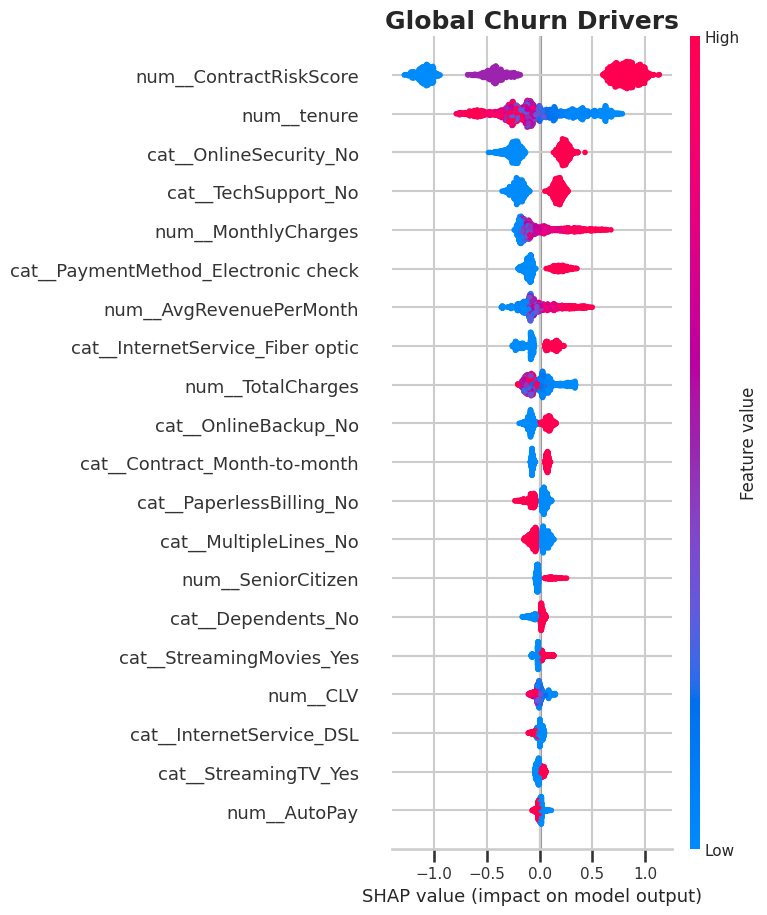

In [ ]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title(
    "Global Churn Drivers",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Bar Importance Plot

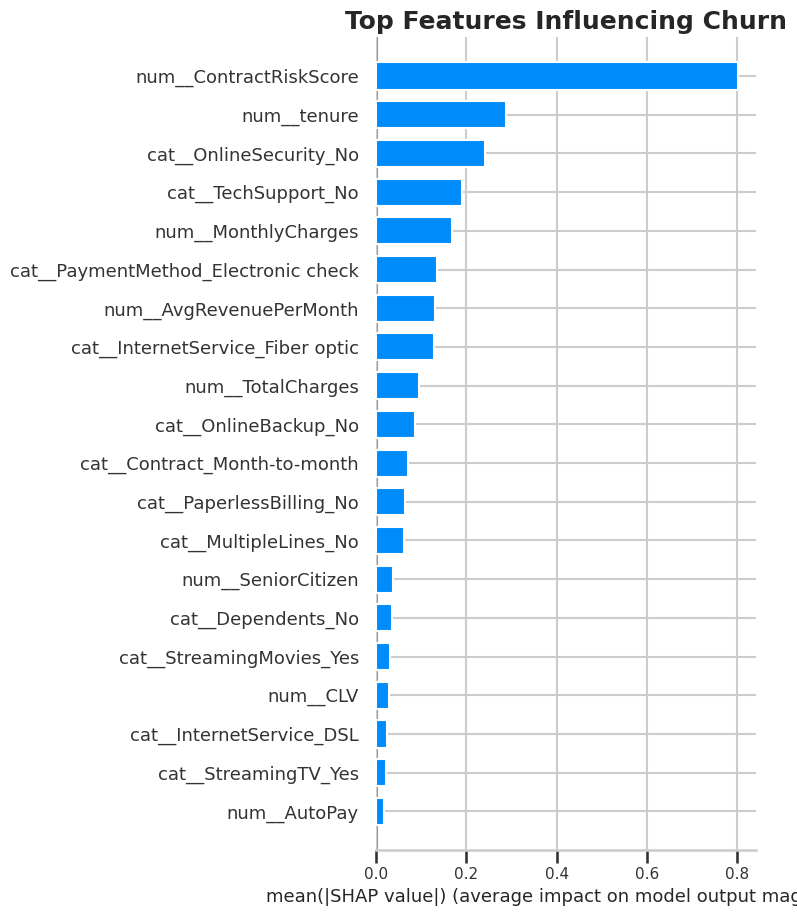

In [ ]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    "Top Features Influencing Churn",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Waterfall Plot
This explains ONE customer.

In [ ]:
customer_idx = 10

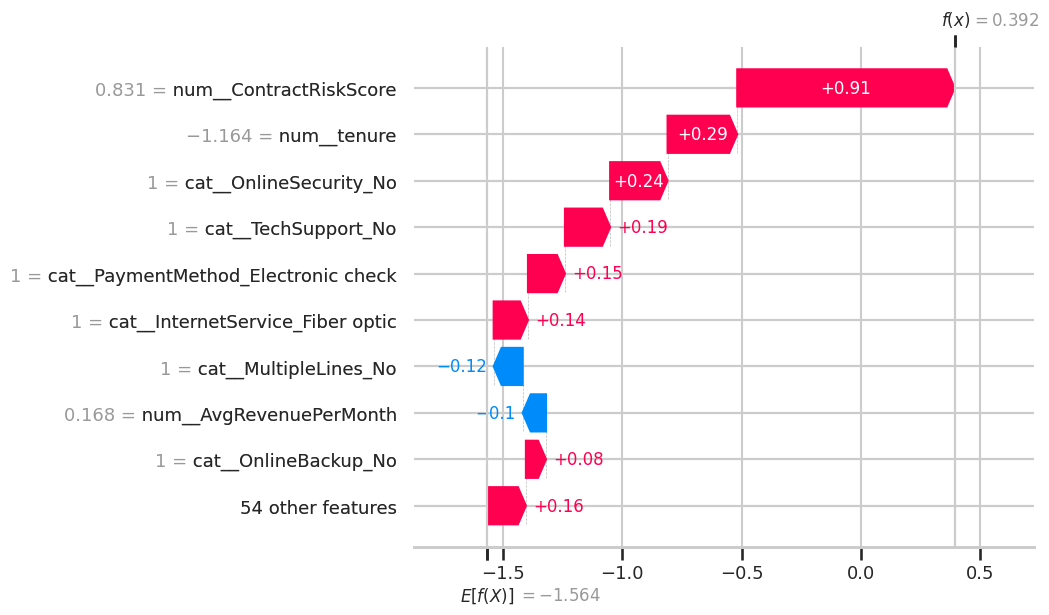

In [ ]:
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[customer_idx],

        base_values=explainer.expected_value,

        data=X_test_processed[customer_idx],

        feature_names=feature_names
    )

)

Customer Churn Risk = 87%

Reasons:

+ Month-to-month contract
+ High monthly charges
+ No tech support
+ No online security

Reduced Risk:

- Long tenure
- Partner

## Force Plot

In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_processed[0],
    feature_names=feature_names
)

## Create Business KPIs

In [ ]:
test_results = X_test.copy()

test_results["Churn_Probability"] = best_lgbm.predict_proba(
    X_test_processed
)[:,1]

## Risk Category

In [ ]:
def risk_category(prob):

    if prob >= 0.75:
        return "Critical"

    elif prob >= 0.50:
        return "High"

    elif prob >= 0.25:
        return "Medium"

    return "Low"

In [ ]:
test_results["RiskCategory"] = (
    test_results["Churn_Probability"]
    .apply(risk_category)
)

## Revenue at Risk

In [ ]:
test_results["RevenueAtRisk"] = (
    test_results["MonthlyCharges"]
    *
    test_results["Churn_Probability"]
)

Customer is High Risk

Reason:
No Online Security

Recommendation:
Offer Security Bundle Discount

## Create Full Prediction Dataset

In [ ]:
full_data = fe_df.copy()

## Process Data

In [ ]:
X_full = full_data.drop(
    columns=["Churn"]
)

X_full_processed = preprocessor.transform(
    X_full
)

## Predict Churn Probability

In [ ]:
full_data["ChurnProbability"] = (
    best_lgbm.predict_proba(
        X_full_processed
    )[:,1]
)

## Risk Segmentation

In [ ]:
def risk_segment(prob):

    if prob >= 0.75:
        return "Critical"

    elif prob >= 0.50:
        return "High"

    elif prob >= 0.25:
        return "Medium"

    return "Low"

In [ ]:
full_data["RiskSegment"] = (
    full_data["ChurnProbability"]
    .apply(risk_segment)
)

## Segment Distribution

In [ ]:
full_data["RiskSegment"].value_counts()

,count
RiskSegment,
Low,4015
Medium,1504
High,1148
Critical,365


## High-Level Visualization

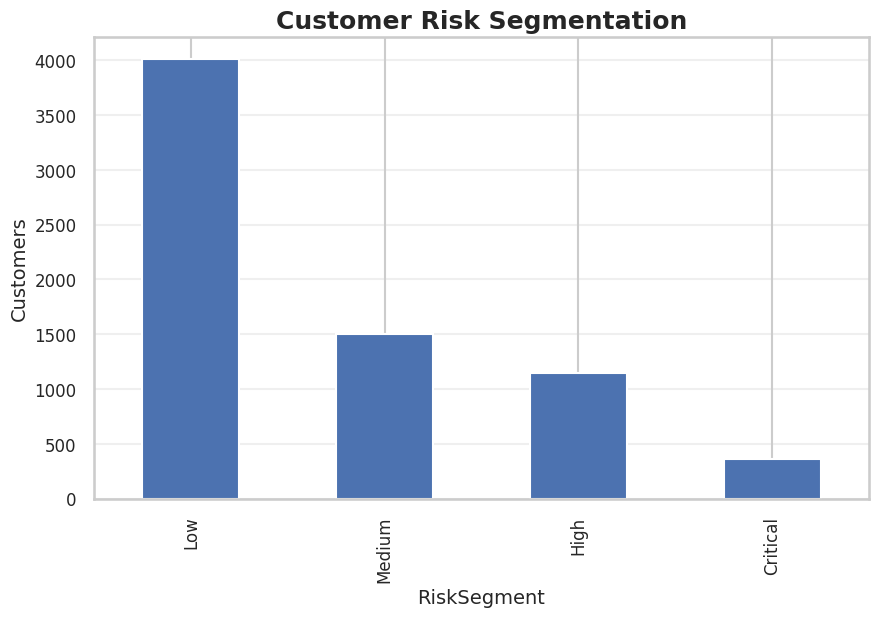

In [ ]:
import matplotlib.pyplot as plt

risk_counts = (
    full_data["RiskSegment"]
    .value_counts()
)

plt.figure(figsize=(10,6))

risk_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Risk Segmentation",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel(
    "Customers"
)

plt.grid(
    axis="y",
    alpha=0.3
)
plt.show()

## Revenue at Risk

In [ ]:
full_data["RevenueAtRisk"] = (

    full_data["MonthlyCharges"]

    *

    full_data["ChurnProbability"]

)

## Executive KPIs

In [ ]:
print(
    "Total Revenue At Risk:",
    round(
        full_data["RevenueAtRisk"].sum(),
        2
    )
)

print(
    "Average Churn Probability:",
    round(
        full_data["ChurnProbability"].mean(),
        4
    )
)

print(
    "High Risk Customers:",
    (
        full_data["RiskSegment"]
        .isin(
            ["High","Critical"]
        )
    ).sum()
)

Total Revenue At Risk: 139063.92
Average Churn Probability: 0.2672
High Risk Customers: 1513


## Then Create Top 100 Customers At Risk

In [ ]:
top_risk_customers = (

    full_data

    .sort_values(
        "ChurnProbability",
        ascending=False
    )

    .head(100)

)

## Save For Dashboard

In [ ]:
top_risk_customers.to_csv(
    "top_risk_customers.csv",
    index=False
)

full_data.to_csv(
    "dashboard_dataset.csv",
    index=False
)

## Revenue at Risk by Segment

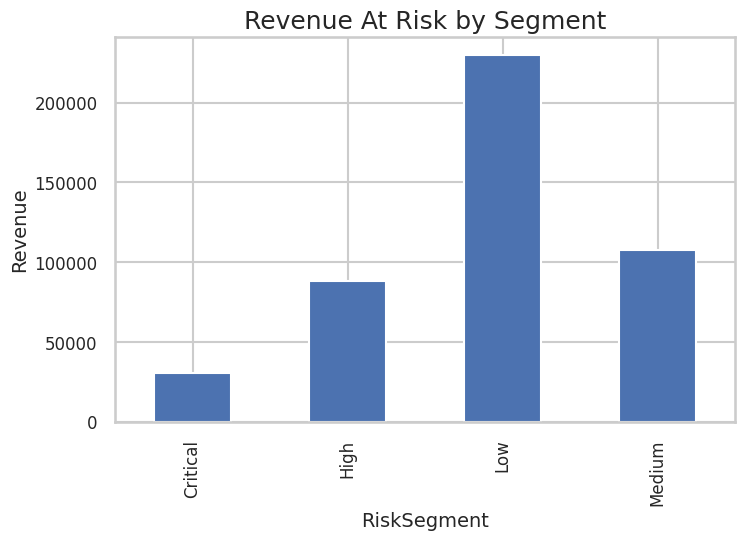

In [ ]:
segment_revenue = full_data.groupby("RiskSegment")["MonthlyCharges"].sum()

segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue At Risk by Segment")
plt.ylabel("Revenue")
plt.show()

## Churn Probability Distribution

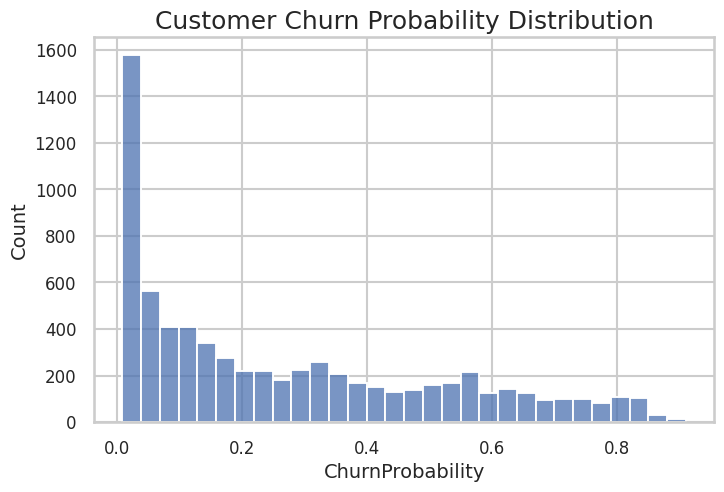

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    full_data["ChurnProbability"],
    bins=30
)

plt.title("Customer Churn Probability Distribution")
plt.show()

## Actual Churn vs Predicted Churn

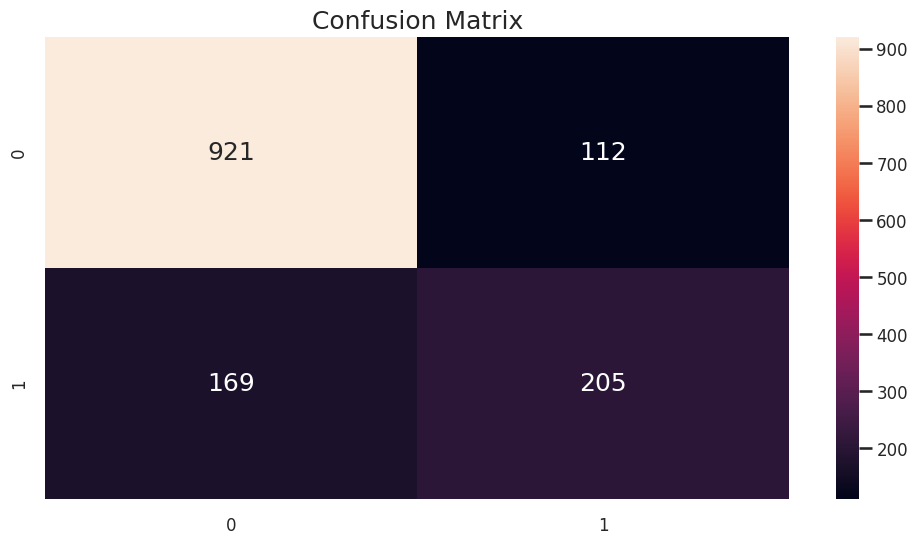

In [ ]:
y_pred = best_lgbm.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

## ROC Curve

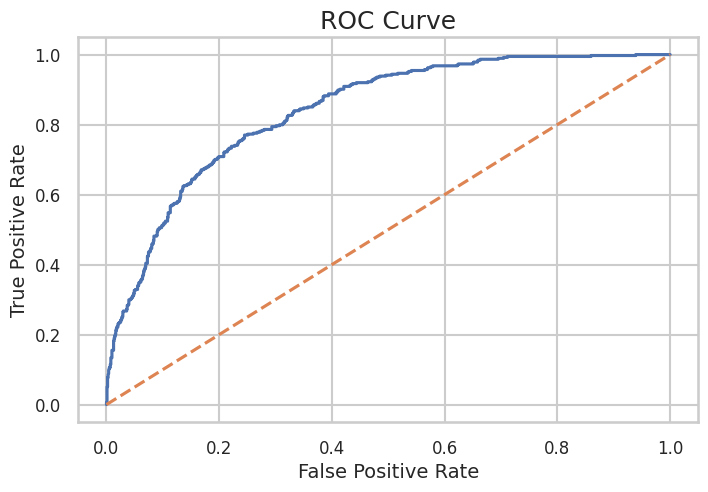

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Dashboard Dataset

## Create Recommendations

In [ ]:
def retention_strategy(prob):

    if prob >= 0.80:
        return "Retention Agent + Discount"

    elif prob >= 0.60:
        return "Offer Upgrade Package"

    elif prob >= 0.40:
        return "Send Promotional Email"

    else:
        return "No Action"

## Create Churn Probabilities

In [ ]:
churn_prob = best_xgb.predict_proba(X_full_processed)[:,1]

## Create Risk Segments

In [ ]:
def risk_segment(prob):

    if prob < 0.25:
        return "Low"

    elif prob < 0.50:
        return "Medium"

    elif prob < 0.75:
        return "High"

    else:
        return "Critical"

## Build Dashboard DataFrame

In [ ]:
dashboard_df = df.copy()

dashboard_df["ChurnProbability"] = churn_prob

dashboard_df["RiskSegment"] = (
    dashboard_df["ChurnProbability"]
    .apply(risk_segment)
)

dashboard_df["Recommendation"] = (
    dashboard_df["ChurnProbability"]
    .apply(retention_strategy)
)

dashboard_df["PredictedChurn"] = (
    dashboard_df["ChurnProbability"] >= 0.50
).astype(int)

## Select Important Columns

In [ ]:
dashboard_df["customerID"] = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")["customerID"]

In [ ]:
dashboard_df = dashboard_df[
    [
        "customerID",
        "ChurnProbability",
        "RiskSegment",
        "Recommendation",
        "MonthlyCharges",
        "TotalCharges",
        "tenure",
        "PredictedChurn"
    ]
]

In [ ]:
dashboard_df.head()

,customerID,ChurnProbability,RiskSegment,Recommendation,MonthlyCharges,TotalCharges,tenure,PredictedChurn
0,7590-VHVEG,0.678269,High,Offer Upgrade Package,29.85,29.85,1,1
1,5575-GNVDE,0.044923,Low,No Action,56.95,1889.50,34,0
2,3668-QPYBK,0.396430,Medium,No Action,53.85,108.15,2,0
3,7795-CFOCW,0.042699,Low,No Action,42.30,1840.75,45,0
4,9237-HQITU,0.618582,High,Offer Upgrade Package,70.70,151.65,2,1


In [ ]:
dashboard_df.to_csv(
    "dashboard_data.csv",
    index=False
)

print("Dashboard dataset saved.")

Dashboard dataset saved.


In [ ]:
dashboard_df.shape

(7032, 8)